Sales Analytics & Business Intelligence Dashboard

1. Data Loading

In [356]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [357]:

customers = pd.read_csv("../data/customers.csv")
products = pd.read_csv("../data/products.csv")
orders = pd.read_csv("../data/orders.csv")

In [358]:
customers.head()


,CustomerID,CustomerName,City,Age,Gender,Email
0,10001,Aditya Chauhan,Surat,20.0,Male,customer1@example.com
1,10002,Ishaan Singh,Chennai,38.0,Female,customer2@example.com
2,10003,Aamir Desai,Nagpur,37.0,Female,customer3@example.com
3,10004,Aditya Ansari,Lucknow,29.0,Female,customer4@example.com
4,10005,Rahul Khan,Ahmedabad,23.0,Male,customer5@example.com


In [359]:
products.head()


,ProductID,Product,Category,Price
0,20001,Laptop 1,Electronics,63388
1,20002,Laptop 2,Electronics,66297
2,20003,Laptop 3,Electronics,53620
3,20004,Laptop 4,Electronics,68919
4,20005,Smartphone 1,Electronics,55986


In [360]:
orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8


In [361]:
print(f"Customers Shape : {customers.shape}")
print(f"Orders Shape    : {orders.shape}")
print(f"Products Shape  : {products.shape}")

Customers Shape : (600, 6)
Orders Shape    : (10020, 10)
Products Shape  : (104, 4)


In [362]:
print("CUSTOMERS")
print(customers.columns)

print("\nPRODUCTS")
print(products.columns)

print("\nORDERS")
print(orders.columns)

CUSTOMERS
Index(['CustomerID', 'CustomerName', 'City', 'Age', 'Gender', 'Email'], dtype='str')

PRODUCTS
Index(['ProductID', 'Product', 'Category', 'Price'], dtype='str')

ORDERS
Index(['OrderID', 'OrderDate', 'CustomerID', 'ProductID', 'Quantity',
       'PaymentMethod', 'OrderStatus', 'Price', 'DiscountPercent',
       'FinalAmount'],
      dtype='str')


2. Dataset Overview

In [363]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CustomerID    600 non-null    int64  
 1   CustomerName  600 non-null    str    
 2   City          596 non-null    str    
 3   Age           596 non-null    float64
 4   Gender        600 non-null    str    
 5   Email         600 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 28.3 KB


In [364]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to 10019
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   OrderID          10020 non-null  int64  
 1   OrderDate        10020 non-null  str    
 2   CustomerID       10020 non-null  int64  
 3   ProductID        10020 non-null  int64  
 4   Quantity         10012 non-null  float64
 5   PaymentMethod    10012 non-null  str    
 6   OrderStatus      10011 non-null  str    
 7   Price            10020 non-null  int64  
 8   DiscountPercent  10020 non-null  int64  
 9   FinalAmount      10020 non-null  float64
dtypes: float64(2), int64(5), str(3)
memory usage: 782.9 KB


In [365]:
products.info()

<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProductID  104 non-null    int64
 1   Product    104 non-null    str  
 2   Category   104 non-null    str  
 3   Price      104 non-null    int64
dtypes: int64(2), str(2)
memory usage: 3.4 KB


In [366]:
customers.describe()

,CustomerID,Age
count,600.000000,596.000000
mean,10300.500000,38.701342
std,173.349358,12.432868
min,10001.000000,18.000000
25%,10150.750000,28.000000
50%,10300.500000,37.000000
75%,10450.250000,50.000000
max,10600.000000,60.000000


In [367]:
orders.describe()

,OrderID,CustomerID,ProductID,Quantity,Price,DiscountPercent,FinalAmount
count,10020.000000,10020.000000,10020.000000,10012.000000,10020.000000,10020.000000,10020.000000
mean,505000.277944,10297.551597,20052.385629,2.394626,12310.540020,6.979042,27678.395070
std,2886.236160,172.312423,30.081186,1.420832,15304.851902,7.473249,44178.689415
min,500001.000000,10001.000000,20001.000000,1.000000,412.000000,0.000000,329.600000
25%,502501.750000,10149.000000,20026.000000,1.000000,2774.000000,0.000000,4592.337500
50%,505001.500000,10297.000000,20053.000000,2.000000,6711.000000,5.000000,11910.000000
75%,507497.250000,10447.000000,20078.000000,4.000000,15742.000000,15.000000,29946.000000
max,510000.000000,10600.000000,20104.000000,5.000000,68919.000000,20.000000,344595.000000


In [368]:
products.describe()

,ProductID,Price
count,104.000000,104.000000
mean,20052.500000,11969.682692
std,30.166206,14844.331981
min,20001.000000,412.000000
25%,20026.750000,2724.250000
50%,20052.500000,6476.000000
75%,20078.250000,15433.750000
max,20104.000000,68919.000000


In [369]:
customers.isnull().sum()

CustomerID      0
CustomerName    0
City            4
Age             4
Gender          0
Email           0
dtype: int64

In [370]:
products.isnull().sum()

ProductID    0
Product      0
Category     0
Price        0
dtype: int64

In [371]:
orders.isnull().sum()

OrderID            0
OrderDate          0
CustomerID         0
ProductID          0
Quantity           8
PaymentMethod      8
OrderStatus        9
Price              0
DiscountPercent    0
FinalAmount        0
dtype: int64

In [372]:
customers.duplicated().sum()

np.int64(0)

In [373]:
orders.duplicated().sum()

np.int64(20)

In [374]:
products.duplicated().sum()

np.int64(0)

In [375]:
print(f"{customers["City"].unique()}")
print(f"The Total Unique Value is {customers["City"].nunique()}")

<StringArray>
[    'Surat',   'Chennai',    'Nagpur',   'Lucknow', 'Ahmedabad',   'Kolkata',
    'Jaipur',      'Pune',    'Mumbai',     'Delhi', 'Hyderabad', 'Bangalore',
         nan]
Length: 13, dtype: str
The Total Unique Value is 12


In [376]:
print(f"{customers["Gender"].unique()}")
print(f"The Total Unique Value is {customers["Gender"].nunique()}")


<StringArray>
['Male', 'Female']
Length: 2, dtype: str
The Total Unique Value is 2


In [377]:
print(f"{products["Category"].unique()}")
print(f"The Total Unique Value is {products["Category"].nunique()}")


<StringArray>
['Electronics', 'Furniture', 'Clothing', 'Home & Kitchen', 'Beauty']
Length: 5, dtype: str
The Total Unique Value is 5


In [378]:
print(f"{orders["PaymentMethod"].unique()}")
print(f"The Total Unique Value is {orders["PaymentMethod"].nunique()}")


<StringArray>
['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'Net Banking', nan]
Length: 6, dtype: str
The Total Unique Value is 5


In [379]:
print(f"{orders["OrderStatus"].unique()}")
print(f"The Total Unique Value is {orders["OrderStatus"].nunique()}")


<StringArray>
['Delivered', 'Returned', 'Cancelled', nan]
Length: 4, dtype: str
The Total Unique Value is 3


In [380]:
orders['CustomerID'].count()

np.int64(10020)

In [381]:
orders['CustomerID'].nunique()

600

In [382]:
orders["ProductID"].nunique()

104

In [383]:
orders["OrderID"].nunique()

10000

In [384]:
print("===== CUSTOMERS INFO =====")
customers.info()

print("\n===== PRODUCTS INFO =====")
products.info()

print("\n===== ORDERS INFO =====")
orders.info()

===== CUSTOMERS INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 600 entries, 0 to 599
Data columns (total 6 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   CustomerID    600 non-null    int64  
 1   CustomerName  600 non-null    str    
 2   City          596 non-null    str    
 3   Age           596 non-null    float64
 4   Gender        600 non-null    str    
 5   Email         600 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 28.3 KB

===== PRODUCTS INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 104 entries, 0 to 103
Data columns (total 4 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   ProductID  104 non-null    int64
 1   Product    104 non-null    str  
 2   Category   104 non-null    str  
 3   Price      104 non-null    int64
dtypes: int64(2), str(2)
memory usage: 3.4 KB

===== ORDERS INFO =====
<class 'pandas.DataFrame'>
RangeIndex: 10020 entries, 0 to

In [385]:
print("===== CUSTOMERS MISSING VALUES =====")
print(customers.isnull().sum())

print("\n===== PRODUCTS MISSING VALUES =====")
print(products.isnull().sum())

print("\n===== ORDERS MISSING VALUES =====")
print(orders.isnull().sum())

===== CUSTOMERS MISSING VALUES =====
CustomerID      0
CustomerName    0
City            4
Age             4
Gender          0
Email           0
dtype: int64

===== PRODUCTS MISSING VALUES =====
ProductID    0
Product      0
Category     0
Price        0
dtype: int64

===== ORDERS MISSING VALUES =====
OrderID            0
OrderDate          0
CustomerID         0
ProductID          0
Quantity           8
PaymentMethod      8
OrderStatus        9
Price              0
DiscountPercent    0
FinalAmount        0
dtype: int64


In [386]:
print("===== DUPLICATES =====")

print("Customers:", customers.duplicated().sum())
print("Products :", products.duplicated().sum())
print("Orders   :", orders.duplicated().sum())

===== DUPLICATES =====
Customers: 0
Products : 0
Orders   : 20


In [387]:
print("===== UNIQUE VALUES =====")

print("Cities:", customers["City"].unique())
print("Gender:", customers["Gender"].unique())

print("Categories:", products["Category"].unique())

print("Payment Methods:", orders["PaymentMethod"].unique())

print("Order Status:", orders["OrderStatus"].unique())

===== UNIQUE VALUES =====
Cities: <StringArray>
[    'Surat',   'Chennai',    'Nagpur',   'Lucknow', 'Ahmedabad',   'Kolkata',
    'Jaipur',      'Pune',    'Mumbai',     'Delhi', 'Hyderabad', 'Bangalore',
         nan]
Length: 13, dtype: str
Gender: <StringArray>
['Male', 'Female']
Length: 2, dtype: str
Categories: <StringArray>
['Electronics', 'Furniture', 'Clothing', 'Home & Kitchen', 'Beauty']
Length: 5, dtype: str
Payment Methods: <StringArray>
['Debit Card', 'UPI', 'Credit Card', 'Cash on Delivery', 'Net Banking', nan]
Length: 6, dtype: str
Order Status: <StringArray>
['Delivered', 'Returned', 'Cancelled', nan]
Length: 4, dtype: str


3. Data Cleaning

In [388]:
customers_clean = customers.copy()
products_clean = products.copy()
orders_clean = orders.copy()

In [389]:
customers_clean["City"].isnull().sum()

np.int64(4)

In [390]:
customers_clean["City"] = customers_clean["City"].fillna("Unknown")

In [391]:
customers_clean["City"].isnull().sum()

np.int64(0)

In [392]:
customers_clean["Age"].isnull().sum()

np.int64(4)

In [393]:
medianage = customers_clean['Age'].median()
customers_clean["Age"] = customers_clean["Age"].fillna(medianage)

In [394]:
customers_clean["Age"].isnull().sum()

np.int64(0)

In [395]:
products_clean.isnull().sum()

ProductID    0
Product      0
Category     0
Price        0
dtype: int64

In [396]:
orders_clean["Quantity"].isnull().sum()

np.int64(8)

In [397]:
median_quantity = orders_clean["Quantity"].median()

orders_clean["Quantity"] = orders_clean["Quantity"].fillna(
    median_quantity
)

In [398]:
orders_clean["Quantity"].isnull().sum()

np.int64(0)

In [399]:
orders_clean['PaymentMethod'].isnull().sum()

np.int64(8)

In [400]:
orders_clean['PaymentMethod'] = orders_clean['PaymentMethod'].fillna("Unknown")

In [401]:
orders_clean["PaymentMethod"].isnull().sum()

np.int64(0)

In [402]:
orders_clean['OrderStatus'].isnull().sum()

np.int64(9)

In [403]:
orders_clean['OrderStatus'] = orders_clean['OrderStatus'].fillna("Unknown")

In [404]:
orders_clean["OrderStatus"].isnull().sum()

np.int64(0)

In [405]:
orders_clean.duplicated().sum()

np.int64(20)

In [406]:
orders_clean = orders_clean.drop_duplicates()

In [407]:
orders_clean.duplicated().sum()

np.int64(0)

In [408]:
orders_clean.shape

(10000, 10)

In [409]:
orders_clean["OrderDate"].dtype

<StringDtype(storage='python', na_value=nan)>

In [410]:
orders_clean["OrderDate"] = pd.to_datetime(
    orders_clean["OrderDate"]
)

In [411]:
orders_clean["OrderDate"].dtype

dtype('<M8[ns]')

In [412]:
print("===== CUSTOMERS =====")
print(customers_clean.isnull().sum())

print("\n===== PRODUCTS =====")
print(products_clean.isnull().sum())

print("\n===== ORDERS =====")
print(orders_clean.isnull().sum())

===== CUSTOMERS =====
CustomerID      0
CustomerName    0
City            0
Age             0
Gender          0
Email           0
dtype: int64

===== PRODUCTS =====
ProductID    0
Product      0
Category     0
Price        0
dtype: int64

===== ORDERS =====
OrderID            0
OrderDate          0
CustomerID         0
ProductID          0
Quantity           0
PaymentMethod      0
OrderStatus        0
Price              0
DiscountPercent    0
FinalAmount        0
dtype: int64


In [413]:
print("Customers duplicates:", customers_clean.duplicated().sum())
print("Products duplicates:", products_clean.duplicated().sum())
print("Orders duplicates:", orders_clean.duplicated().sum())

Customers duplicates: 0
Products duplicates: 0
Orders duplicates: 0


In [414]:
print("Customers:", customers_clean.shape)
print("Products :", products_clean.shape)
print("Orders   :", orders_clean.shape)

Customers: (600, 6)
Products : (104, 4)
Orders   : (10000, 10)


4. Data Transformation

In [415]:
orders.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8


In [416]:
orders_clean['Rvenuew'] = (orders_clean['Quantity'] * orders_clean['Price'])

In [417]:
orders_clean.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Rvenuew
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0,5560.0
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8,8328.0


In [418]:
orders_clean[
    ["OrderID", "Quantity", "Price", "Rvenuew"]
].head()

,OrderID,Quantity,Price,Rvenuew
0,500001,2.0,4109,8218.0
1,500002,1.0,13717,13717.0
2,500003,4.0,23385,93540.0
3,500004,4.0,1390,5560.0
4,500005,2.0,4164,8328.0


In [419]:
orders_clean = orders_clean.rename(columns={'Rvenuew': 'Revenue'})


In [420]:
orders_clean.head()


,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Revenue
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0,5560.0
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8,8328.0


In [421]:
orders_clean['DiscountAmount'] = (orders_clean['Revenue'] * orders_clean['DiscountPercent']/100)

In [422]:
orders_clean.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Revenue,DiscountAmount
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0,0.0
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0,0.0
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0,4677.0
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0,5560.0,1112.0
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8,8328.0,1249.2


In [423]:
orders_clean[
    [
        "OrderID",
        "Revenue",
        "DiscountPercent",
        "DiscountAmount",
        "FinalAmount"
    ]
].head()

,OrderID,Revenue,DiscountPercent,DiscountAmount,FinalAmount
0,500001,8218.0,0,0.0,8218.0
1,500002,13717.0,0,0.0,13717.0
2,500003,93540.0,5,4677.0,88863.0
3,500004,5560.0,20,1112.0,4448.0
4,500005,8328.0,15,1249.2,7078.8


In [424]:
orders_clean['Year'] = (orders_clean['OrderDate']).dt.year

In [425]:
orders_clean.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Revenue,DiscountAmount,Year
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0,0.0,2025
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0,0.0,2025
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0,4677.0,2025
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0,5560.0,1112.0,2025
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8,8328.0,1249.2,2025


In [426]:
orders_clean["MonthNumber"] = (
    orders_clean["OrderDate"].dt.month
)

In [427]:
orders_clean["Month"] = (
    orders_clean["OrderDate"].dt.month_name()
)

In [428]:
orders_clean.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Revenue,DiscountAmount,Year,MonthNumber,Month
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0,0.0,2025,10,October
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0,0.0,2025,10,October
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0,4677.0,2025,10,October
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0,5560.0,1112.0,2025,10,October
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8,8328.0,1249.2,2025,10,October


In [429]:
orders_clean["Quarter"] = (
    orders_clean["OrderDate"].dt.quarter
)

In [430]:
orders_clean["Quarter"] = (
    "Q" +
    orders_clean["OrderDate"].dt.quarter.astype(str)
)

In [431]:
orders_clean["DayName"] = (
    orders_clean["OrderDate"].dt.day_name()
)

In [432]:
orders_clean.head(3)

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Revenue,DiscountAmount,Year,MonthNumber,Month,Quarter,DayName
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0,0.0,2025,10,October,Q4,Wednesday
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0,0.0,2025,10,October,Q4,Wednesday
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0,4677.0,2025,10,October,Q4,Wednesday


In [433]:
orders_clean['OrderValueCategory'] = np.where(
    orders_clean['FinalAmount'] >= 50000,
    "High Value",
np.where(
    orders_clean['FinalAmount'] >= 10000,
    "Medium Value",
    "Low Value"
))

In [434]:
orders_clean[
    ["FinalAmount", "OrderValueCategory"]
].head(10)

,FinalAmount,OrderValueCategory
0,8218.0,Low Value
1,13717.0,Medium Value
2,88863.0,High Value
3,4448.0,Low Value
4,7078.8,Low Value
5,15742.0,Medium Value
6,44447.4,Medium Value
7,3398.3,Low Value
8,4248.0,Low Value
9,12942.1,Medium Value


In [435]:
orders_clean.columns

Index(['OrderID', 'OrderDate', 'CustomerID', 'ProductID', 'Quantity',
       'PaymentMethod', 'OrderStatus', 'Price', 'DiscountPercent',
       'FinalAmount', 'Revenue', 'DiscountAmount', 'Year', 'MonthNumber',
       'Month', 'Quarter', 'DayName', 'OrderValueCategory'],
      dtype='str')

In [436]:
orders_clean.columns.value_counts().sum()

np.int64(18)

In [437]:
orders_clean.columns.value_counts()

OrderID               1
OrderDate             1
CustomerID            1
ProductID             1
Quantity              1
PaymentMethod         1
OrderStatus           1
Price                 1
DiscountPercent       1
FinalAmount           1
Revenue               1
DiscountAmount        1
Year                  1
MonthNumber           1
Month                 1
Quarter               1
DayName               1
OrderValueCategory    1
Name: count, dtype: int64

In [438]:
orders_clean.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Revenue,DiscountAmount,Year,MonthNumber,Month,Quarter,DayName,OrderValueCategory
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0,0.0,2025,10,October,Q4,Wednesday,Low Value
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0,0.0,2025,10,October,Q4,Wednesday,Medium Value
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0,4677.0,2025,10,October,Q4,Wednesday,High Value
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0,5560.0,1112.0,2025,10,October,Q4,Wednesday,Low Value
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8,8328.0,1249.2,2025,10,October,Q4,Wednesday,Low Value


In [439]:
orders_clean.shape

(10000, 18)

In [440]:
orders_clean["Revenue"].sum()

np.float64(297164402.0)

In [441]:
orders_clean["FinalAmount"].sum()

np.float64(276740826.05)

In [442]:
orders_clean["Revenue"] = (
    orders_clean["Quantity"] *
    orders_clean["Price"]
)

orders_clean["DiscountAmount"] = (
    orders_clean["Revenue"] *
    orders_clean["DiscountPercent"] / 100
)

orders_clean["Year"] = (
    orders_clean["OrderDate"].dt.year
)

orders_clean["MonthNumber"] = (
    orders_clean["OrderDate"].dt.month
)

orders_clean["Month"] = (
    orders_clean["OrderDate"].dt.month_name()
)

orders_clean["Quarter"] = (
    "Q" +
    orders_clean["OrderDate"].dt.quarter.astype(str)
)

orders_clean["DayName"] = (
    orders_clean["OrderDate"].dt.day_name()
)

orders_clean["OrderValueCategory"] = np.where(
    orders_clean["FinalAmount"] >= 50000,
    "High Value",
    np.where(
        orders_clean["FinalAmount"] >= 10000,
        "Medium Value",
        "Low Value"
    )
)

In [443]:
orders_clean[
    [
        "OrderID",
        "OrderDate",
        "Quantity",
        "Price",
        "Revenue",
        "DiscountAmount",
        "FinalAmount",
        "Year",
        "Month",
        "Quarter",
        "OrderValueCategory"
    ]
].head(10)

,OrderID,OrderDate,Quantity,Price,Revenue,DiscountAmount,FinalAmount,Year,Month,Quarter,OrderValueCategory
0,500001,2025-10-01 00:00:00.000000000,2.0,4109,8218.0,0.0,8218.0,2025,October,Q4,Low Value
1,500002,2025-10-01 00:51:42.070207020,1.0,13717,13717.0,0.0,13717.0,2025,October,Q4,Medium Value
2,500003,2025-10-01 01:43:24.140414041,4.0,23385,93540.0,4677.0,88863.0,2025,October,Q4,High Value
3,500004,2025-10-01 02:35:06.210621062,4.0,1390,5560.0,1112.0,4448.0,2025,October,Q4,Low Value
4,500005,2025-10-01 03:26:48.280828082,2.0,4164,8328.0,1249.2,7078.8,2025,October,Q4,Low Value
5,500006,2025-10-01 04:18:30.351035103,1.0,15742,15742.0,0.0,15742.0,2025,October,Q4,Medium Value
6,500007,2025-10-01 05:10:12.421242124,2.0,24693,49386.0,4938.6,44447.4,2025,October,Q4,Medium Value
7,500008,2025-10-01 06:01:54.491449144,2.0,1999,3998.0,599.7,3398.3,2025,October,Q4,Low Value
8,500009,2025-10-01 06:53:36.561656165,1.0,4248,4248.0,0.0,4248.0,2025,October,Q4,Low Value
9,500010,2025-10-01 07:45:18.631863186,2.0,7613,15226.0,2283.9,12942.1,2025,October,Q4,Medium Value


In [444]:
orders_clean["OrderDateOnly"] = (
    orders_clean["OrderDate"].dt.date
)

In [445]:
orders_clean[
    ["OrderDate", "OrderDateOnly"]
].head()

,OrderDate,OrderDateOnly
0,2025-10-01 00:00:00.000000000,2025-10-01
1,2025-10-01 00:51:42.070207020,2025-10-01
2,2025-10-01 01:43:24.140414041,2025-10-01
3,2025-10-01 02:35:06.210621062,2025-10-01
4,2025-10-01 03:26:48.280828082,2025-10-01


5. Exploratory Data Analysis

In [446]:
total_revenue = orders_clean["Revenue"].sum()

print("Total Revenue:", total_revenue)

Total Revenue: 297164402.0


In [447]:
total_final_amount = orders_clean["FinalAmount"].sum()

print("Total Sales Amount:", total_final_amount)

Total Sales Amount: 276740826.05


In [448]:
total_orders = orders_clean["OrderID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 10000


In [449]:
total_orders = orders_clean["OrderID"].nunique()

print("Total Orders:", total_orders)

Total Orders: 10000


In [450]:
total_quantity_sold = orders_clean["Quantity"].sum()

print("Total Products Sold:", total_quantity_sold)

Total Products Sold: 23942.0


In [451]:
average_order_value = (
    orders_clean["FinalAmount"].sum()
    / orders_clean["OrderID"].nunique()
)



In [452]:
print(f"Average Order Value:", {round(average_order_value,2)})

Average Order Value: {np.float64(27674.08)}


In [453]:
total_discount = orders_clean["DiscountAmount"].sum()

print("Total Discount:", total_discount)


Total Discount: 20637154.15


In [455]:
total_customers = orders_clean["CustomerID"].nunique()

print("Total Customers:", total_customers)

Total Customers: 600


In [456]:
print("========== BUSINESS KPIs ==========")

print("Total Revenue        :", round(total_revenue, 2))
print("Total Sales Amount   :", round(total_final_amount, 2))
print("Total Orders         :", total_orders)
print("Total Customers      :", total_customers)
print("Total Products Sold  :", total_quantity_sold)
print("Average Order Value  :", round(average_order_value, 2))
print("Total Discount       :", round(total_discount, 2))

========== BUSINESS KPIs ==========
Total Revenue        : 297164402.0
Total Sales Amount   : 276740826.05
Total Orders         : 10000
Total Customers      : 600
Total Products Sold  : 23942.0
Average Order Value  : 27674.08
Total Discount       : 20637154.15


In [457]:
orders_analysis = orders_clean.merge(
    products_clean[
        ["ProductID", "Product", "Category"]
    ],
    on="ProductID",
    how="left"
)

In [458]:
orders_analysis[
    [
        "OrderID",
        "ProductID",
        "Product",
        "Category",
        "Revenue"
    ]
].head()

,OrderID,ProductID,Product,Category,Revenue
0,500001,20024,Headphones 4,Electronics,8218.0
1,500002,20014,Monitor 2,Electronics,13717.0
2,500003,20048,Dining Table 4,Furniture,93540.0
3,500004,20050,T-Shirt 2,Clothing,5560.0
4,500005,20037,Bookshelf 1,Furniture,8328.0


In [459]:
orders_clean.head(3)

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,Revenue,DiscountAmount,Year,MonthNumber,Month,Quarter,DayName,OrderValueCategory,OrderDateOnly
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,8218.0,0.0,2025,10,October,Q4,Wednesday,Low Value,2025-10-01
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,13717.0,0.0,2025,10,October,Q4,Wednesday,Medium Value,2025-10-01
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,93540.0,4677.0,2025,10,October,Q4,Wednesday,High Value,2025-10-01


In [464]:
Category_revenue = (
    orders_analysis.groupby('Category')['Revenue'].sum().sort_values(ascending=False)
)
Category_revenue

Category
Electronics       157525861.0
Furniture          84671637.0
Home & Kitchen     34171302.0
Clothing           13033166.0
Beauty              7762436.0
Name: Revenue, dtype: float64

In [469]:
category_percentage = (
    Category_revenue/Category_revenue.sum() 
)* 100
print(f"{category_percentage.round(2)}")

Category
Electronics       53.01
Furniture         28.49
Home & Kitchen    11.50
Clothing           4.39
Beauty             2.61
Name: Revenue, dtype: float64


In [471]:
category_summary = pd.DataFrame({
    "Revenue": Category_revenue,
    "RevenuePercentage": category_percentage
})

category_summary

,Revenue,RevenuePercentage
Category,,
Electronics,157525861.0,53.009667
Furniture,84671637.0,28.493197
Home & Kitchen,34171302.0,11.499124
Clothing,13033166.0,4.385844
Beauty,7762436.0,2.612169


In [472]:
orders_analysis.head()

,OrderID,OrderDate,CustomerID,ProductID,Quantity,PaymentMethod,OrderStatus,Price,DiscountPercent,FinalAmount,...,DiscountAmount,Year,MonthNumber,Month,Quarter,DayName,OrderValueCategory,OrderDateOnly,Product,Category
0,500001,2025-10-01 00:00:00.000000000,10521,20024,2.0,Debit Card,Delivered,4109,0,8218.0,...,0.0,2025,10,October,Q4,Wednesday,Low Value,2025-10-01,Headphones 4,Electronics
1,500002,2025-10-01 00:51:42.070207020,10375,20014,1.0,UPI,Delivered,13717,0,13717.0,...,0.0,2025,10,October,Q4,Wednesday,Medium Value,2025-10-01,Monitor 2,Electronics
2,500003,2025-10-01 01:43:24.140414041,10600,20048,4.0,UPI,Returned,23385,5,88863.0,...,4677.0,2025,10,October,Q4,Wednesday,High Value,2025-10-01,Dining Table 4,Furniture
3,500004,2025-10-01 02:35:06.210621062,10283,20050,4.0,Credit Card,Delivered,1390,20,4448.0,...,1112.0,2025,10,October,Q4,Wednesday,Low Value,2025-10-01,T-Shirt 2,Clothing
4,500005,2025-10-01 03:26:48.280828082,10369,20037,2.0,Cash on Delivery,Delivered,4164,15,7078.8,...,1249.2,2025,10,October,Q4,Wednesday,Low Value,2025-10-01,Bookshelf 1,Furniture


In [473]:
top_products = (
    orders_analysis
    .groupby("Product")["Revenue"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product
Laptop 4        19779753.0
Laptop 2        19027239.0
Laptop 1        16100552.0
Sofa 2          14665700.0
Laptop 3        14423780.0
Smartphone 1    13380654.0
Sofa 1           8291856.0
Sofa 4           8257032.0
Smartphone 2     8215680.0
Smartphone 4     6964992.0
Name: Revenue, dtype: float64

In [474]:
orders_analysis = orders_analysis.merge(
    customers_clean[
        ["CustomerID", "City"]
    ],
    on="CustomerID",
    how="left"
)

In [475]:
orders_analysis[
    [
        "OrderID",
        "CustomerID",
        "City",
        "Revenue"
    ]
].head()

,OrderID,CustomerID,City,Revenue
0,500001,10521,Delhi,8218.0
1,500002,10375,Delhi,13717.0
2,500003,10600,Kolkata,93540.0
3,500004,10283,Pune,5560.0
4,500005,10369,Surat,8328.0


In [476]:
city_revenue = (
    orders_analysis
    .groupby("City")["Revenue"]
    .sum()
    .sort_values(ascending=False)
)

city_revenue

City
Nagpur       30034553.0
Surat        27567414.0
Ahmedabad    26284715.0
Hyderabad    25002722.0
Kolkata      24913064.0
Delhi        24886454.0
Mumbai       24819986.0
Jaipur       24299174.0
Bangalore    23889944.0
Chennai      22520717.0
Pune         21813680.0
Lucknow      19385605.0
Unknown       1746374.0
Name: Revenue, dtype: float64

In [478]:
payment_counts = (
    orders_clean["PaymentMethod"]
    .value_counts()
)

payment_counts

PaymentMethod
UPI                 3763
Credit Card         2156
Debit Card          1813
Cash on Delivery    1174
Net Banking         1086
Unknown                8
Name: count, dtype: int64

In [479]:
payment_revenue = (
    orders_clean
    .groupby("PaymentMethod")["FinalAmount"]
    .sum()
    .sort_values(ascending=False)
)

payment_revenue

PaymentMethod
UPI                 1.057300e+08
Credit Card         5.885319e+07
Debit Card          5.001948e+07
Cash on Delivery    3.297428e+07
Net Banking         2.878692e+07
Unknown             3.769557e+05
Name: FinalAmount, dtype: float64

In [480]:
monthly_revenue = (
    orders_clean
    .groupby(
        ["Year", "MonthNumber", "Month"]
    )["FinalAmount"]
    .sum()
    .reset_index()
    .sort_values(
        ["Year", "MonthNumber"]
    )
)

In [481]:
monthly_revenue

,Year,MonthNumber,Month,FinalAmount
0,2025,10,October,23813840.65
1,2025,11,November,23474889.50
2,2025,12,December,23594479.90
3,2026,1,January,23602793.30
4,2026,2,February,21670355.15
5,2026,3,March,24639152.00
6,2026,4,April,23551240.55
7,2026,5,May,25912010.40
8,2026,6,June,24570343.40
9,2026,7,July,22384085.45


In [482]:
monthly_revenue["MonthYear"] = (
    monthly_revenue["Year"].astype(str)
    + "-"
    + monthly_revenue["Month"]
)

In [483]:
monthly_revenue[
    [
        "MonthYear",
        "FinalAmount"
    ]
]

,MonthYear,FinalAmount
0,2025-October,23813840.65
1,2025-November,23474889.50
2,2025-December,23594479.90
3,2026-January,23602793.30
4,2026-February,21670355.15
5,2026-March,24639152.00
6,2026-April,23551240.55
7,2026-May,25912010.40
8,2026-June,24570343.40
9,2026-July,22384085.45


In [484]:
order_status = (
    orders_clean["OrderStatus"]
    .value_counts()
)

order_status

OrderStatus
Delivered    6637
Cancelled    1681
Returned     1673
Unknown         9
Name: count, dtype: int64

In [485]:
status_revenue = (
    orders_clean
    .groupby("OrderStatus")["FinalAmount"]
    .sum()
    .sort_values(ascending=False)
)

status_revenue

OrderStatus
Delivered    1.843471e+08
Cancelled    4.826163e+07
Returned     4.402275e+07
Unknown      1.093854e+05
Name: FinalAmount, dtype: float64

In [486]:
category_summary

,Revenue,RevenuePercentage
Category,,
Electronics,157525861.0,53.009667
Furniture,84671637.0,28.493197
Home & Kitchen,34171302.0,11.499124
Clothing,13033166.0,4.385844
Beauty,7762436.0,2.612169


In [488]:
top_products

Product
Laptop 4        19779753.0
Laptop 2        19027239.0
Laptop 1        16100552.0
Sofa 2          14665700.0
Laptop 3        14423780.0
Smartphone 1    13380654.0
Sofa 1           8291856.0
Sofa 4           8257032.0
Smartphone 2     8215680.0
Smartphone 4     6964992.0
Name: Revenue, dtype: float64

In [489]:
orders_analysis[
    ["OrderID", "CustomerID", "City", "Revenue"]
].head()

,OrderID,CustomerID,City,Revenue
0,500001,10521,Delhi,8218.0
1,500002,10375,Delhi,13717.0
2,500003,10600,Kolkata,93540.0
3,500004,10283,Pune,5560.0
4,500005,10369,Surat,8328.0


In [490]:
city_revenue

City
Nagpur       30034553.0
Surat        27567414.0
Ahmedabad    26284715.0
Hyderabad    25002722.0
Kolkata      24913064.0
Delhi        24886454.0
Mumbai       24819986.0
Jaipur       24299174.0
Bangalore    23889944.0
Chennai      22520717.0
Pune         21813680.0
Lucknow      19385605.0
Unknown       1746374.0
Name: Revenue, dtype: float64

In [491]:
payment_counts

PaymentMethod
UPI                 3763
Credit Card         2156
Debit Card          1813
Cash on Delivery    1174
Net Banking         1086
Unknown                8
Name: count, dtype: int64

In [492]:
payment_revenue

PaymentMethod
UPI                 1.057300e+08
Credit Card         5.885319e+07
Debit Card          5.001948e+07
Cash on Delivery    3.297428e+07
Net Banking         2.878692e+07
Unknown             3.769557e+05
Name: FinalAmount, dtype: float64

In [493]:
monthly_revenue

,Year,MonthNumber,Month,FinalAmount,MonthYear
0,2025,10,October,23813840.65,2025-October
1,2025,11,November,23474889.50,2025-November
2,2025,12,December,23594479.90,2025-December
3,2026,1,January,23602793.30,2026-January
4,2026,2,February,21670355.15,2026-February
5,2026,3,March,24639152.00,2026-March
6,2026,4,April,23551240.55,2026-April
7,2026,5,May,25912010.40,2026-May
8,2026,6,June,24570343.40,2026-June
9,2026,7,July,22384085.45,2026-July


In [494]:
order_status

OrderStatus
Delivered    6637
Cancelled    1681
Returned     1673
Unknown         9
Name: count, dtype: int64


Visualization

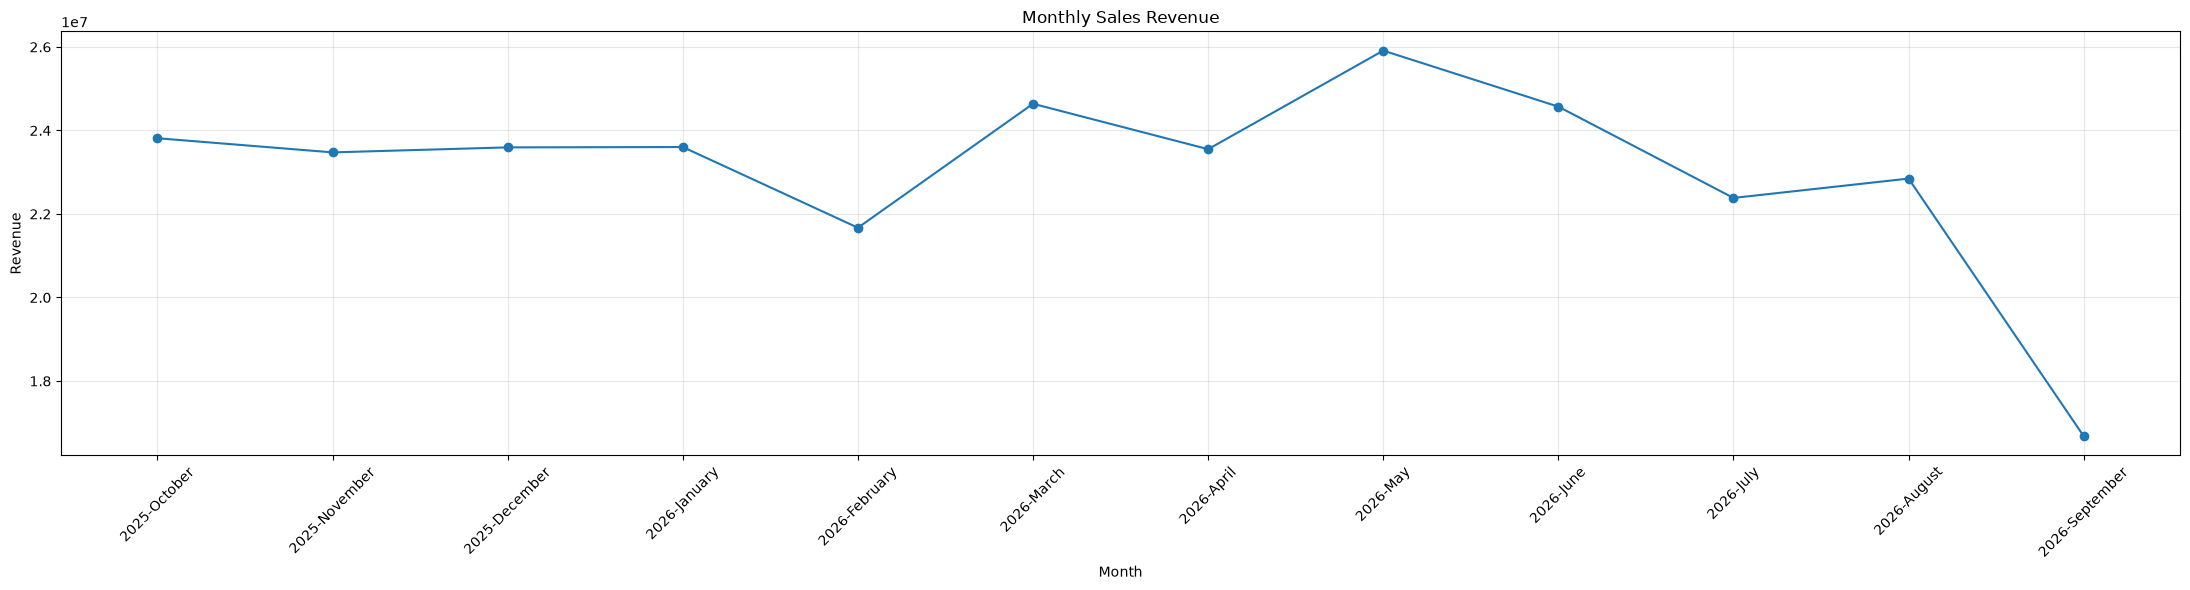

In [504]:
plt.figure(figsize=(22, 6))

plt.plot(
    monthly_revenue["MonthYear"],
    monthly_revenue["FinalAmount"],
    marker="o"
)

plt.title("Monthly Sales Revenue")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

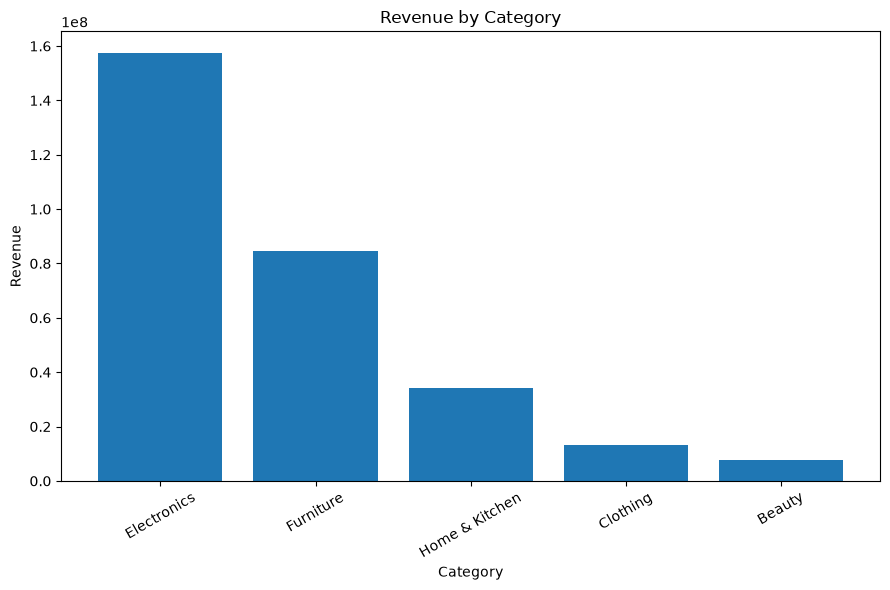

In [505]:
plt.figure(figsize=(9, 6))

plt.bar(
    category_summary.index,
    category_summary["Revenue"]
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

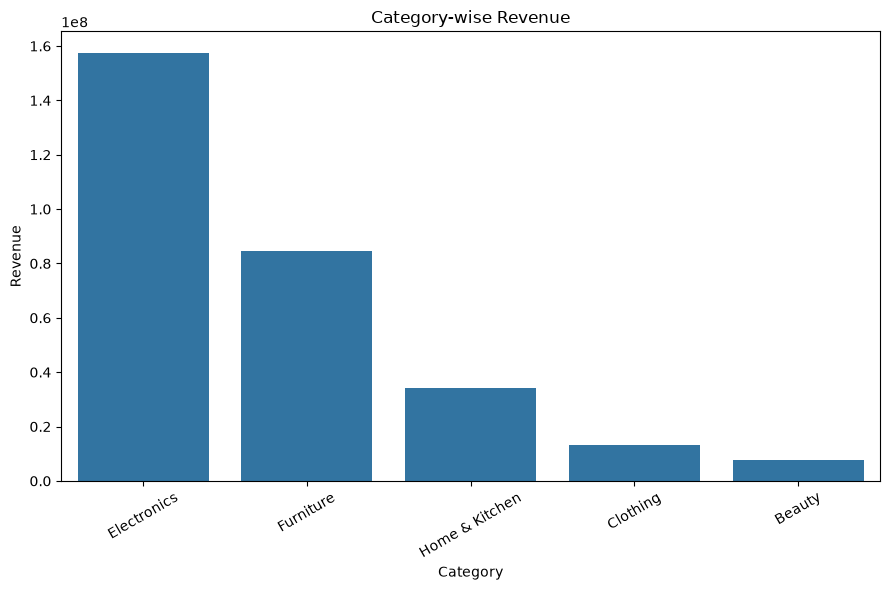

In [506]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=category_summary.reset_index(),
    x="Category",
    y="Revenue"
)

plt.title("Category-wise Revenue")
plt.xlabel("Category")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

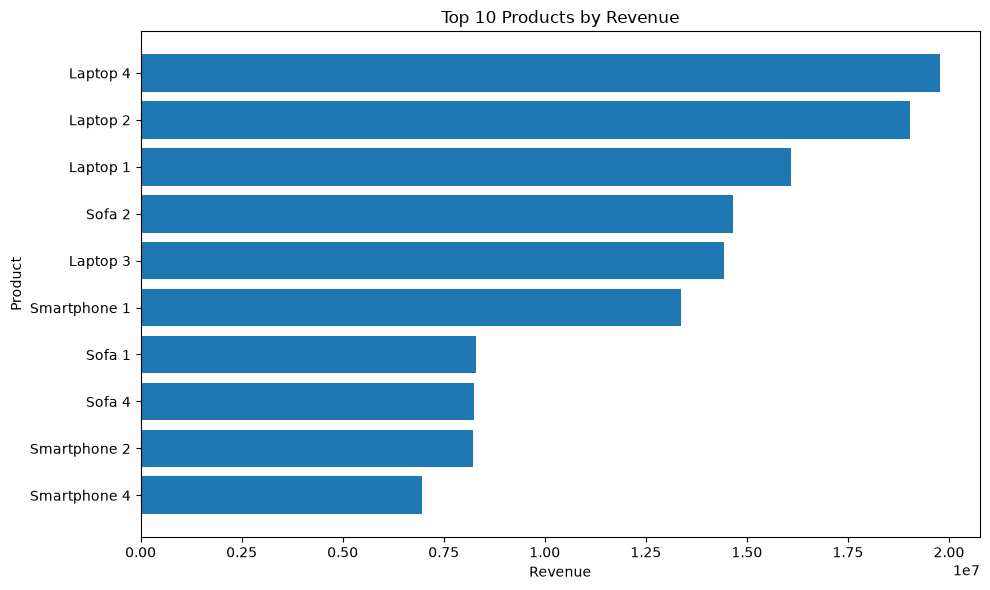

In [507]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Product")

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

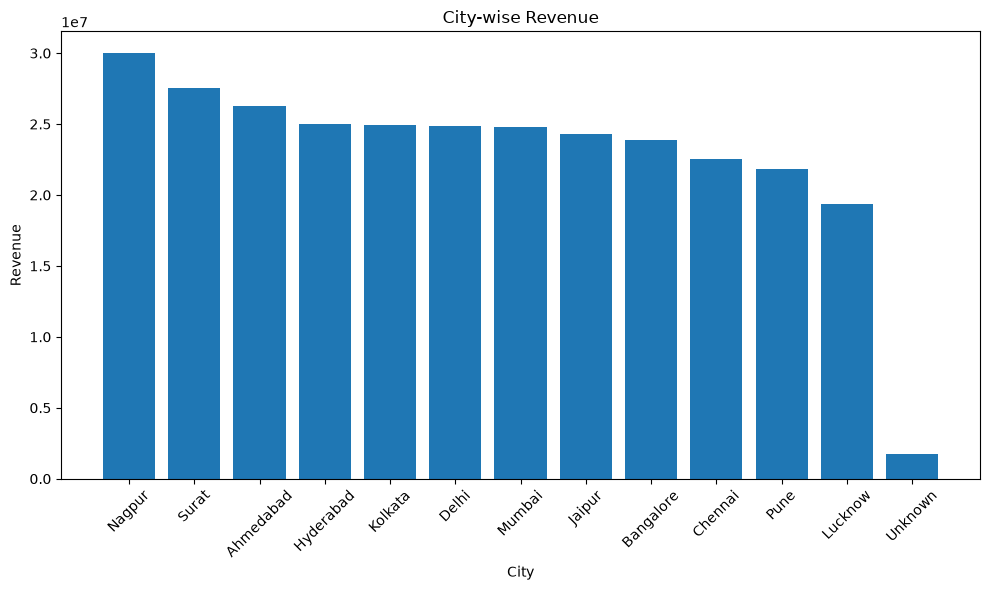

In [508]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_revenue.index,
    city_revenue.values
)

plt.title("City-wise Revenue")
plt.xlabel("City")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

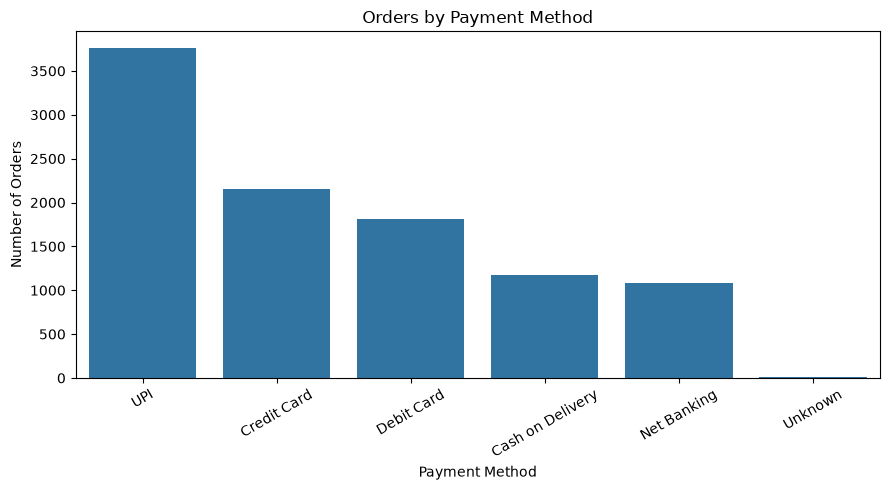

In [509]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_counts.index,
    y=payment_counts.values
)

plt.title("Orders by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

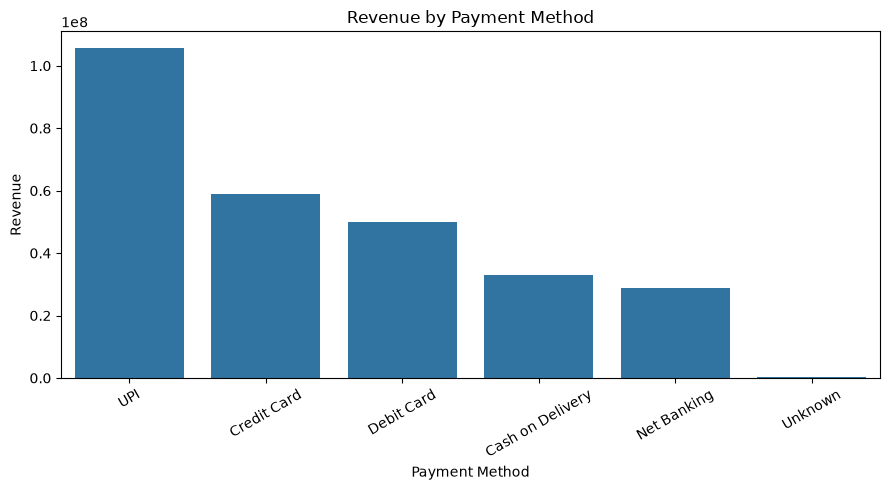

In [510]:
plt.figure(figsize=(9, 5))

sns.barplot(
    x=payment_revenue.index,
    y=payment_revenue.values
)

plt.title("Revenue by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


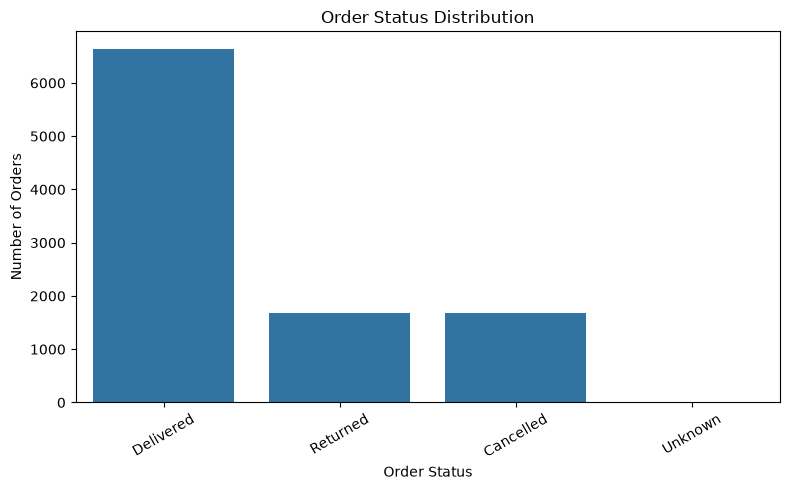

In [511]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_clean,
    x="OrderStatus"
)

plt.title("Order Status Distribution")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

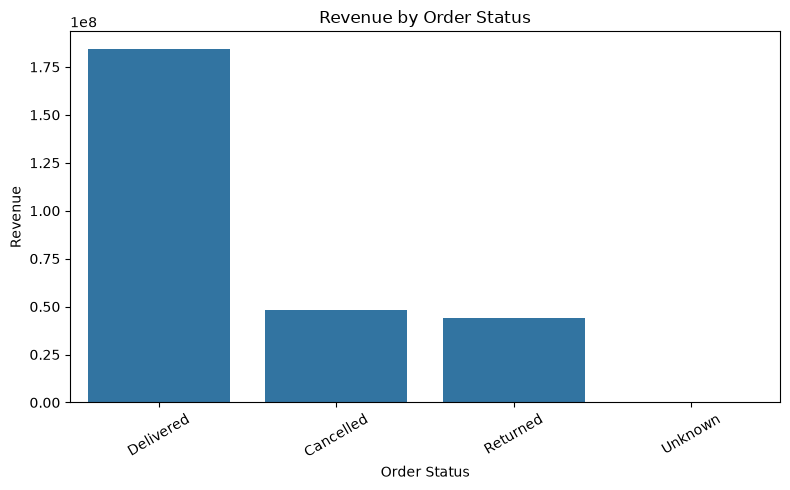

In [512]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=status_revenue.index,
    y=status_revenue.values
)

plt.title("Revenue by Order Status")
plt.xlabel("Order Status")
plt.ylabel("Revenue")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [513]:
numeric_columns = [
    "Quantity",
    "Price",
    "DiscountPercent",
    "FinalAmount",
    "Revenue",
    "DiscountAmount"
]

In [514]:
correlation = orders_clean[numeric_columns].corr()

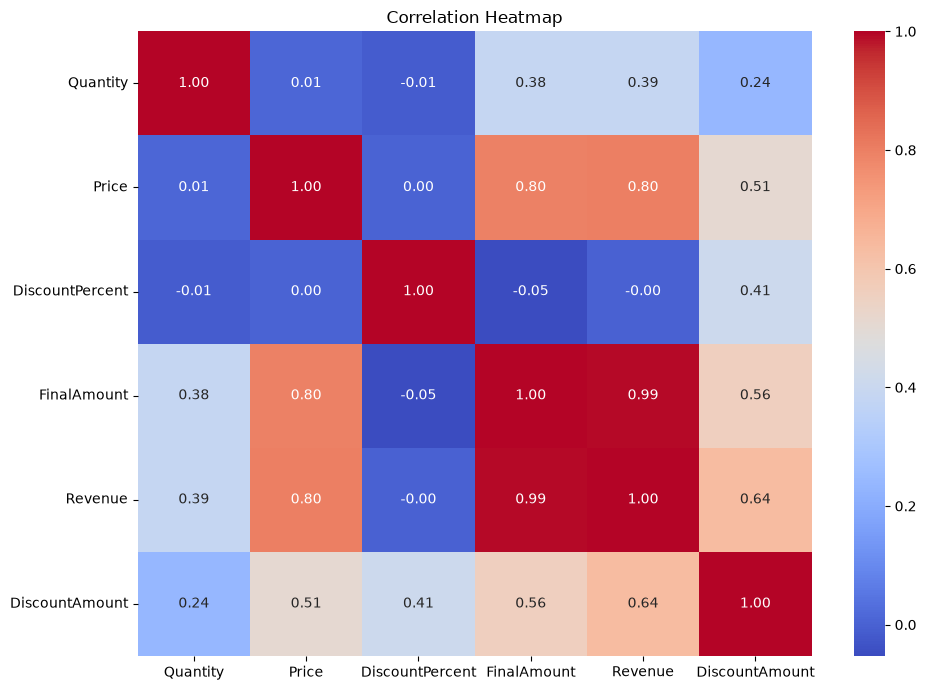

In [515]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f",
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.tight_layout()
plt.show()

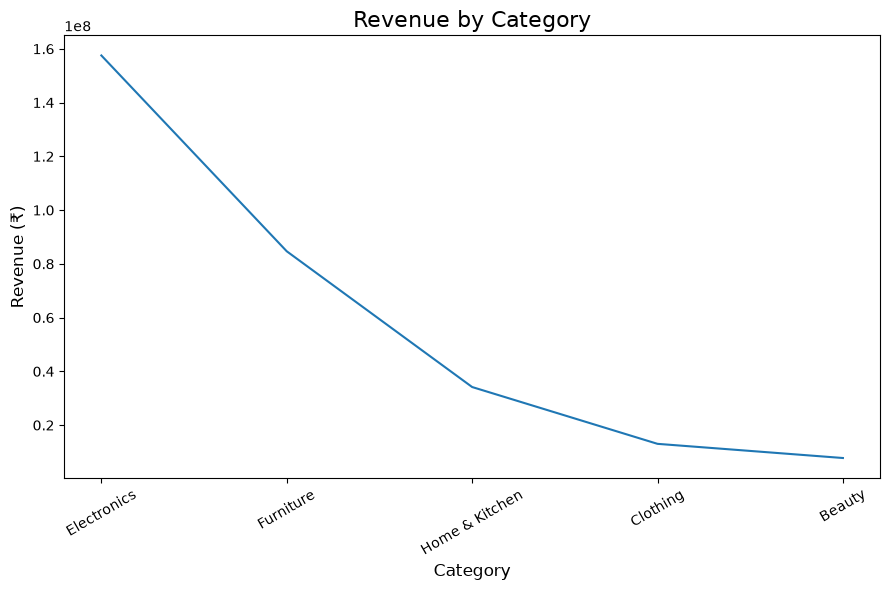

In [519]:
plt.figure(figsize=(9,6))
plt.plot(
    category_summary.index,
    category_summary['Revenue']
)
plt.title("Revenue by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()


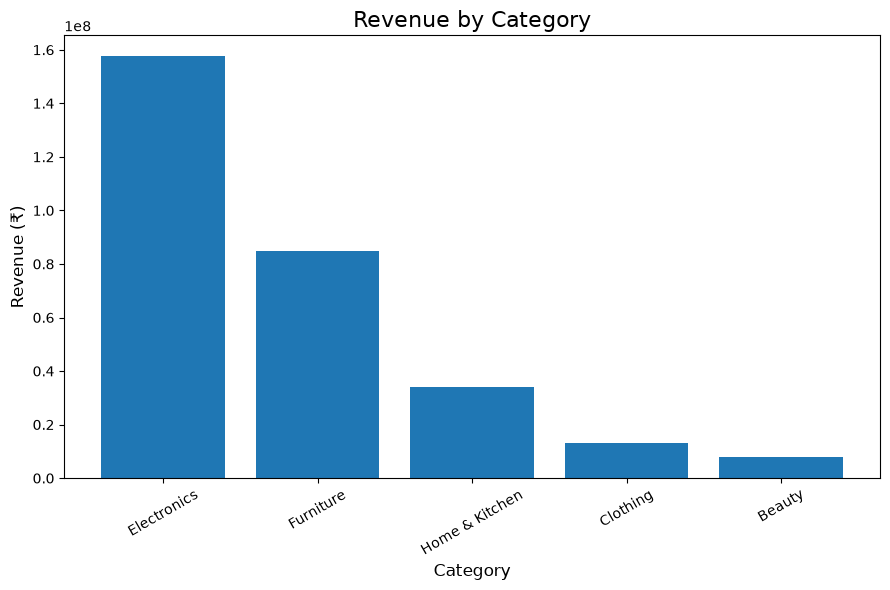

In [520]:
plt.figure(figsize=(9, 6))

plt.bar(
    category_summary.index,
    category_summary["Revenue"]
)

plt.title("Revenue by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

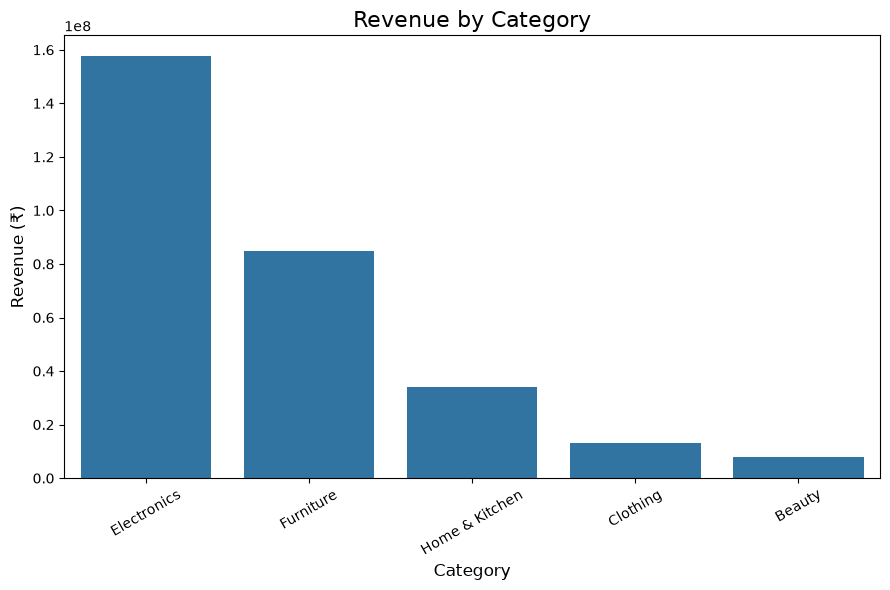

In [521]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=category_summary.reset_index(),
    x="Category",
    y="Revenue"
)

plt.title("Revenue by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [522]:
top_products

Product
Laptop 4        19779753.0
Laptop 2        19027239.0
Laptop 1        16100552.0
Sofa 2          14665700.0
Laptop 3        14423780.0
Smartphone 1    13380654.0
Sofa 1           8291856.0
Sofa 4           8257032.0
Smartphone 2     8215680.0
Smartphone 4     6964992.0
Name: Revenue, dtype: float64

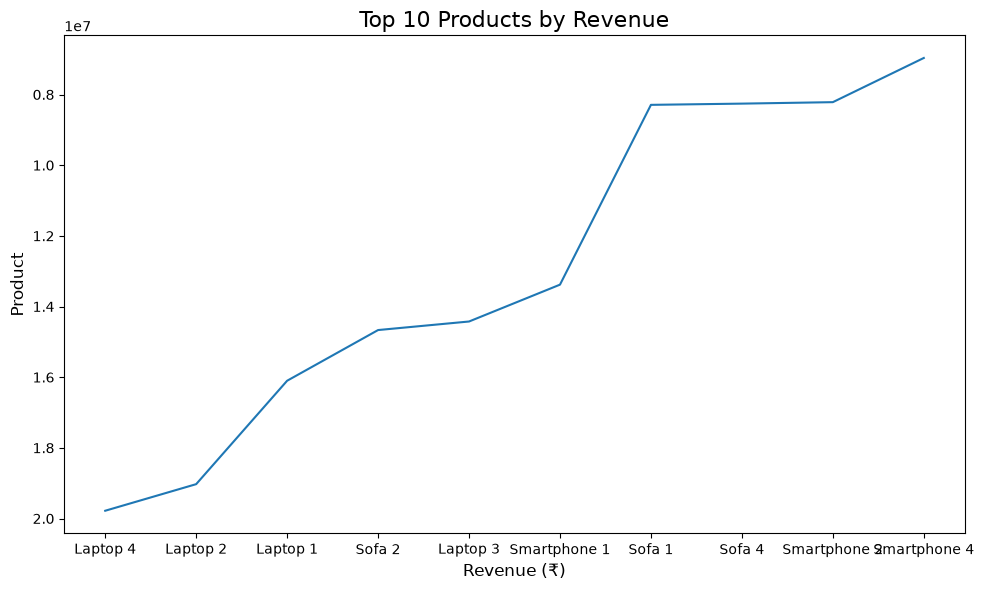

In [523]:
plt.figure(figsize=(10, 6))
plt.plot(
    top_products.index,
    top_products.values
)
plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue (₹)", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

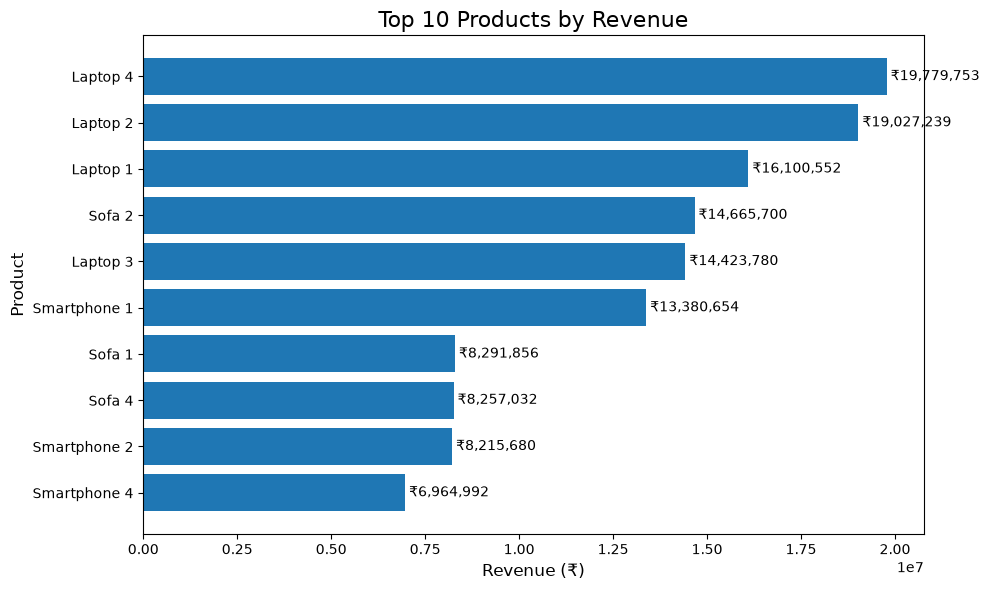

In [524]:
plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue (₹)", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.gca().invert_yaxis()

for bar in bars:
    value = bar.get_width()

    plt.text(
        value,
        bar.get_y() + bar.get_height() / 2,
        f" ₹{value:,.0f}",
        va="center"
    )

plt.tight_layout()
plt.show()

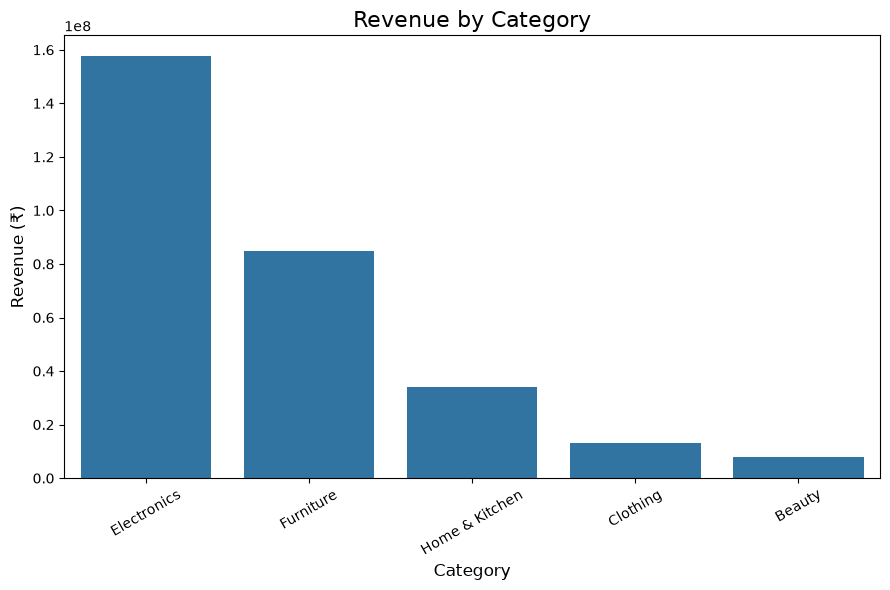

In [525]:
plt.figure(figsize=(9, 6))

sns.barplot(
    data=category_summary.reset_index(),
    x="Category",
    y="Revenue"
)

plt.title("Revenue by Category", fontsize=16)
plt.xlabel("Category", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

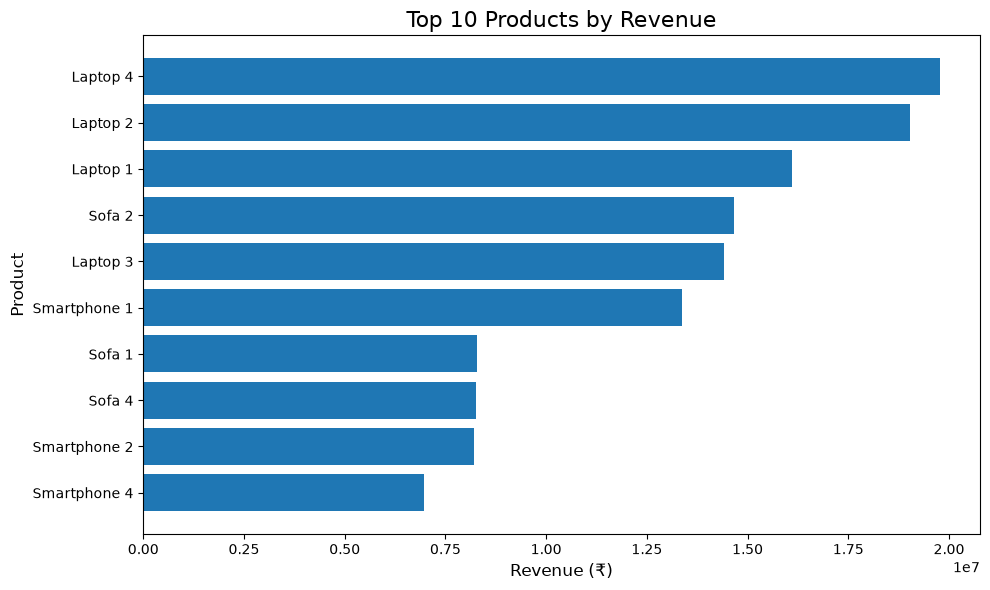

In [526]:
plt.figure(figsize=(10, 6))

plt.barh(
    top_products.index,
    top_products.values
)

plt.title("Top 10 Products by Revenue", fontsize=16)
plt.xlabel("Revenue (₹)", fontsize=12)
plt.ylabel("Product", fontsize=12)

plt.gca().invert_yaxis()

plt.tight_layout()
plt.show()

In [527]:
city_revenue


City
Nagpur       30034553.0
Surat        27567414.0
Ahmedabad    26284715.0
Hyderabad    25002722.0
Kolkata      24913064.0
Delhi        24886454.0
Mumbai       24819986.0
Jaipur       24299174.0
Bangalore    23889944.0
Chennai      22520717.0
Pune         21813680.0
Lucknow      19385605.0
Unknown       1746374.0
Name: Revenue, dtype: float64

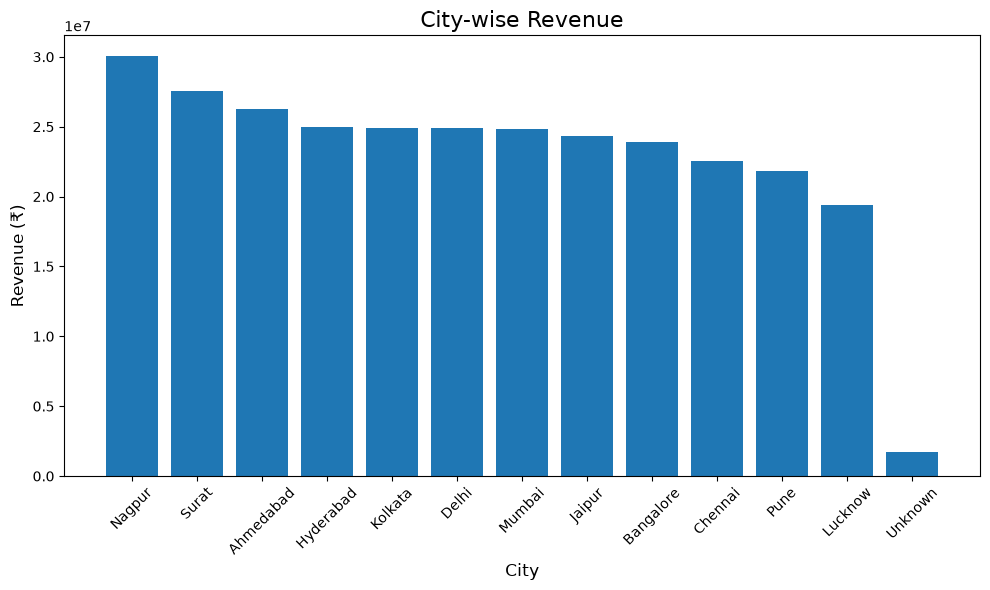

In [528]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_revenue.index,
    city_revenue.values
)

plt.title("City-wise Revenue", fontsize=16)
plt.xlabel("City", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

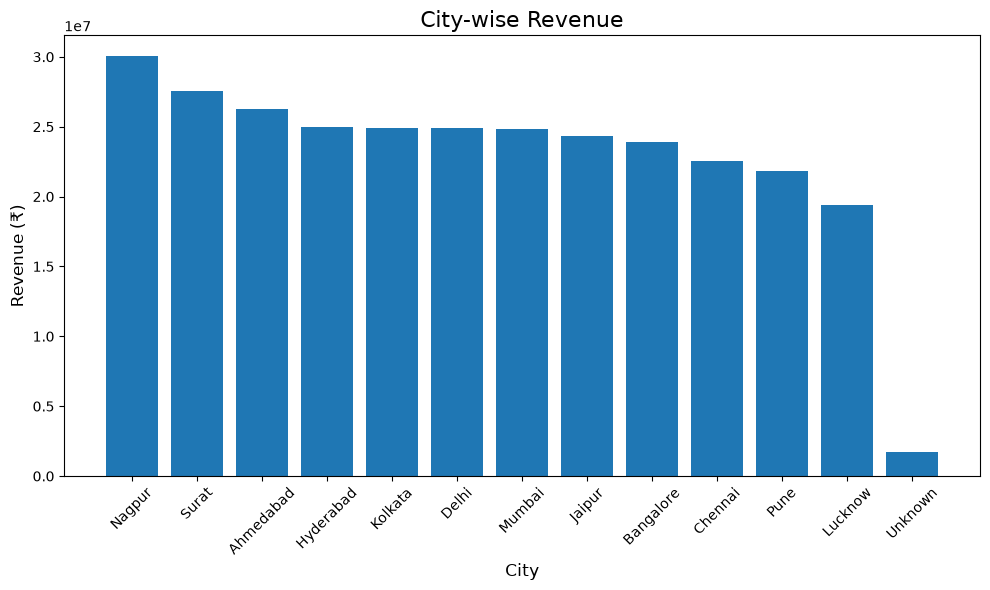

In [529]:
plt.figure(figsize=(10, 6))

plt.bar(
    city_revenue.index,
    city_revenue.values
)

plt.title("City-wise Revenue", fontsize=16)
plt.xlabel("City", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [530]:
payment_counts

PaymentMethod
UPI                 3763
Credit Card         2156
Debit Card          1813
Cash on Delivery    1174
Net Banking         1086
Unknown                8
Name: count, dtype: int64

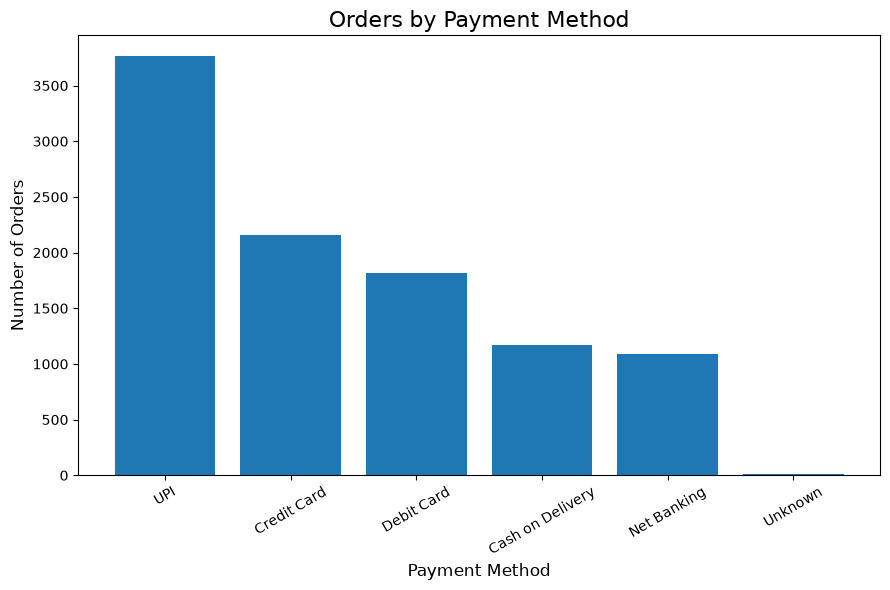

In [531]:
plt.figure(figsize=(9, 6))

plt.bar(
    payment_counts.index,
    payment_counts.values
)

plt.title("Orders by Payment Method", fontsize=16)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

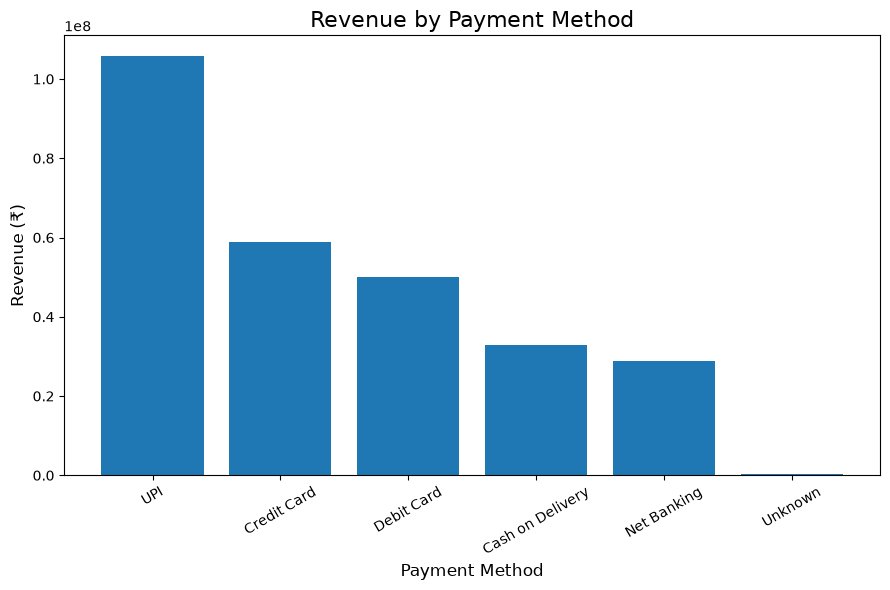

In [532]:
plt.figure(figsize=(9, 6))

plt.bar(
    payment_revenue.index,
    payment_revenue.values
)

plt.title("Revenue by Payment Method", fontsize=16)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

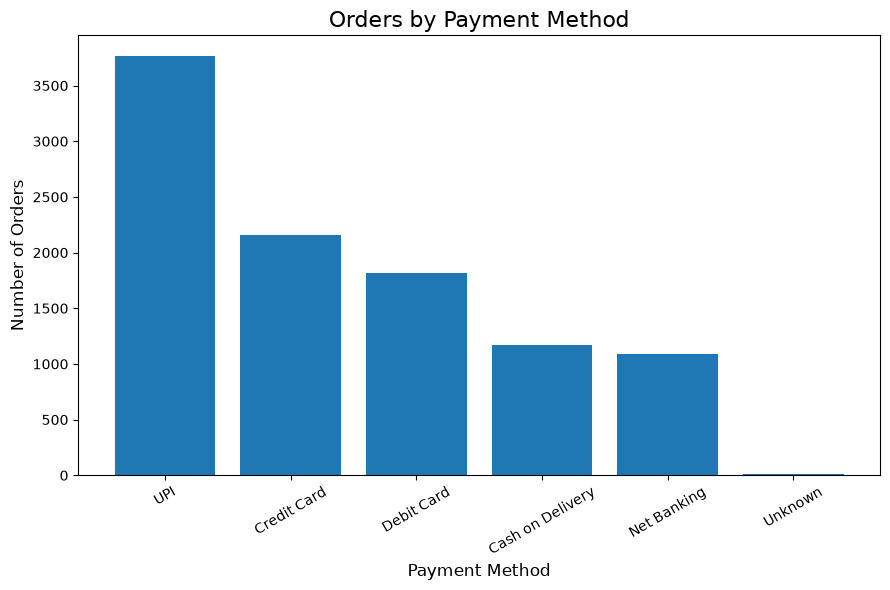

In [533]:
plt.figure(figsize=(9, 6))

plt.bar(
    payment_counts.index,
    payment_counts.values
)

plt.title("Orders by Payment Method", fontsize=16)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

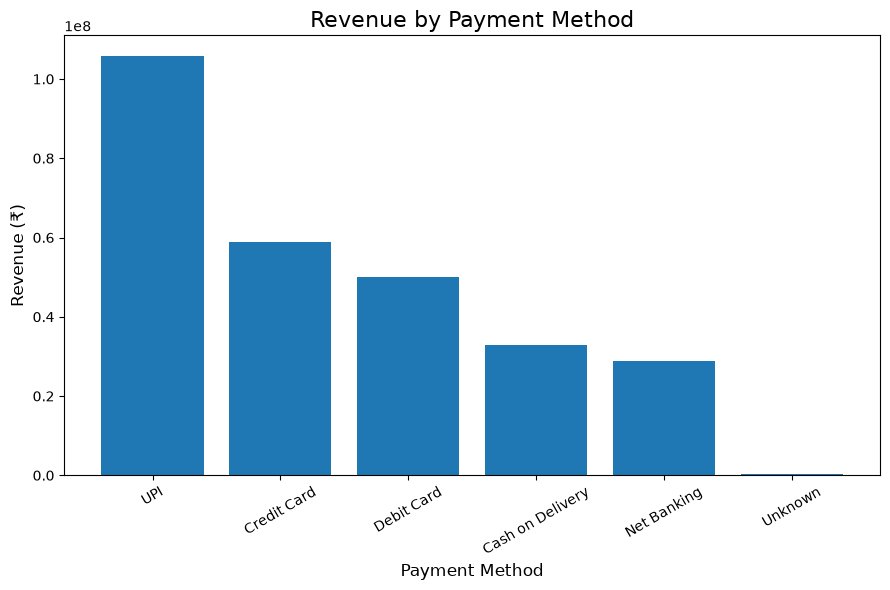

In [534]:
plt.figure(figsize=(9, 6))

plt.bar(
    payment_revenue.index,
    payment_revenue.values
)

plt.title("Revenue by Payment Method", fontsize=16)
plt.xlabel("Payment Method", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [535]:
order_status

OrderStatus
Delivered    6637
Cancelled    1681
Returned     1673
Unknown         9
Name: count, dtype: int64

In [536]:
status_revenue

OrderStatus
Delivered    1.843471e+08
Cancelled    4.826163e+07
Returned     4.402275e+07
Unknown      1.093854e+05
Name: FinalAmount, dtype: float64

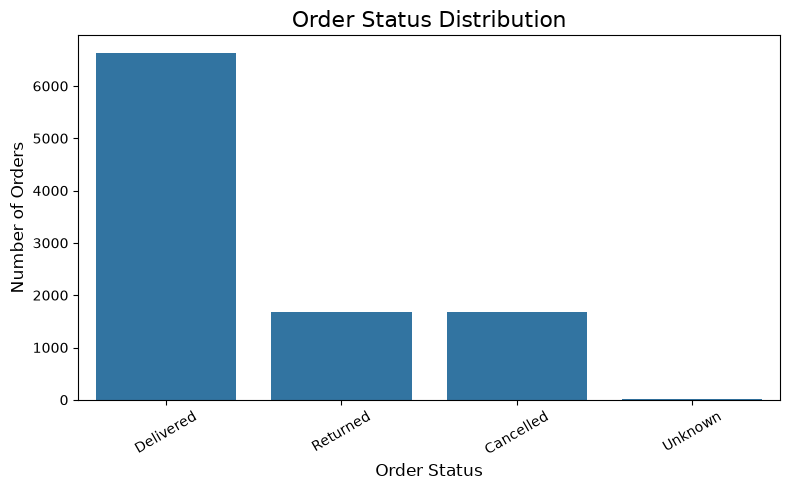

In [537]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_clean,
    x="OrderStatus"
)

plt.title("Order Status Distribution", fontsize=16)
plt.xlabel("Order Status", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

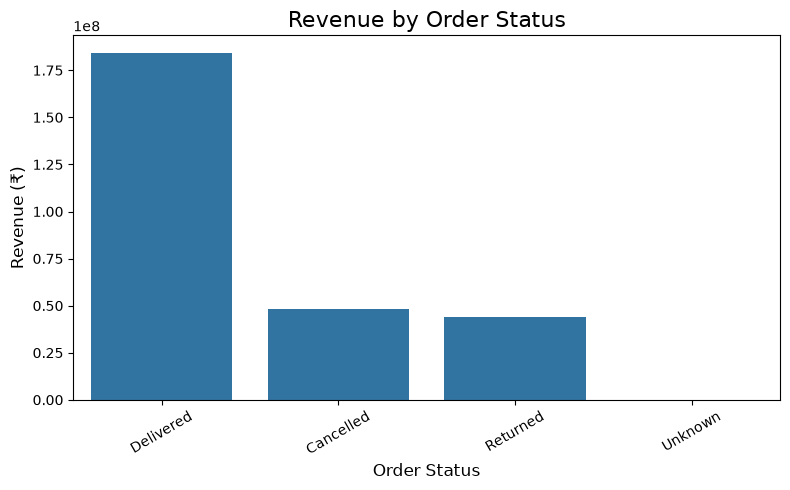

In [538]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=status_revenue.index,
    y=status_revenue.values
)

plt.title("Revenue by Order Status", fontsize=16)
plt.xlabel("Order Status", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [539]:
numeric_columns = [
    "Quantity",
    "Price",
    "DiscountPercent",
    "FinalAmount",
    "Revenue",
    "DiscountAmount"
]

correlation = orders_clean[numeric_columns].corr()

In [540]:
correlation

,Quantity,Price,DiscountPercent,FinalAmount,Revenue,DiscountAmount
Quantity,1.000000,0.010908,-0.012429,0.384898,0.386323,0.236244
Price,0.010908,1.000000,0.000847,0.795909,0.799519,0.508720
DiscountPercent,-0.012429,0.000847,1.000000,-0.052763,-0.003059,0.409958
FinalAmount,0.384898,0.795909,-0.052763,1.000000,0.994680,0.559881
Revenue,0.386323,0.799519,-0.003059,0.994680,1.000000,0.635364
DiscountAmount,0.236244,0.508720,0.409958,0.559881,0.635364,1.000000


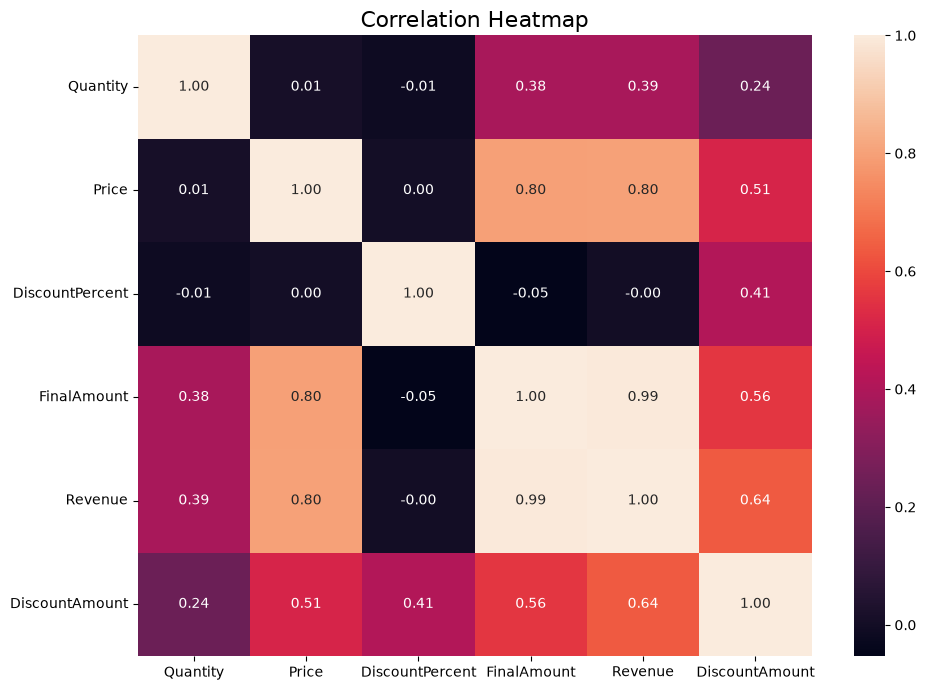

In [541]:
plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()
plt.show()

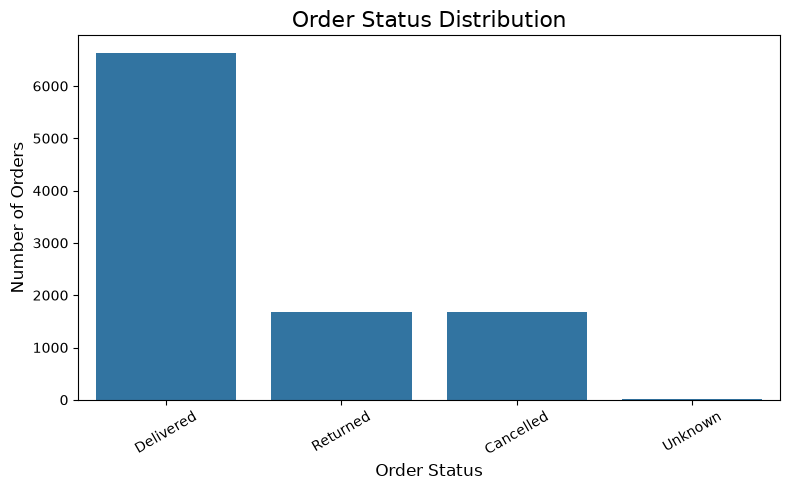

In [542]:
plt.figure(figsize=(8, 5))

sns.countplot(
    data=orders_clean,
    x="OrderStatus"
)

plt.title("Order Status Distribution", fontsize=16)
plt.xlabel("Order Status", fontsize=12)
plt.ylabel("Number of Orders", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

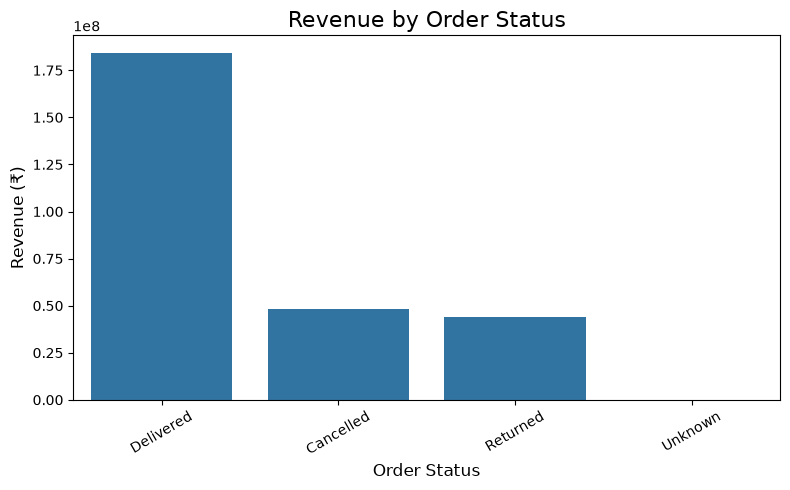

In [543]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=status_revenue.index,
    y=status_revenue.values
)

plt.title("Revenue by Order Status", fontsize=16)
plt.xlabel("Order Status", fontsize=12)
plt.ylabel("Revenue (₹)", fontsize=12)

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

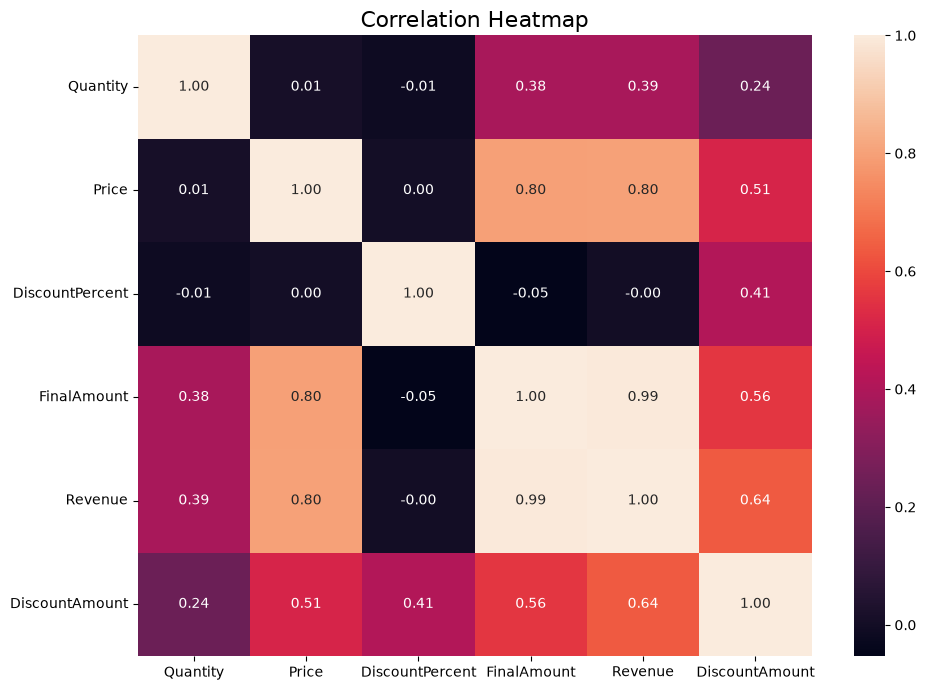

In [544]:
numeric_columns = [
    "Quantity",
    "Price",
    "DiscountPercent",
    "FinalAmount",
    "Revenue",
    "DiscountAmount"
]

correlation = orders_clean[numeric_columns].corr()

plt.figure(figsize=(10, 7))

sns.heatmap(
    correlation,
    annot=True,
    fmt=".2f"
)

plt.title("Correlation Heatmap", fontsize=16)

plt.tight_layout()
plt.show()

10. Business Insights

In [545]:
category_summary

,Revenue,RevenuePercentage
Category,,
Electronics,157525861.0,53.009667
Furniture,84671637.0,28.493197
Home & Kitchen,34171302.0,11.499124
Clothing,13033166.0,4.385844
Beauty,7762436.0,2.612169


In [546]:
category_summary.round(2)

,Revenue,RevenuePercentage
Category,,
Electronics,157525861.0,53.01
Furniture,84671637.0,28.49
Home & Kitchen,34171302.0,11.50
Clothing,13033166.0,4.39
Beauty,7762436.0,2.61


### Product Performance

- Laptop products appear prominently among the top revenue-generating products.
- The Top 10 analysis helps identify products contributing significantly to overall revenue.

### Geographic Performance

- Revenue varies across cities.
- Nagpur generated the highest revenue in the available dataset.
- Surat and Ahmedabad also show relatively high revenue contributions.
- The Unknown category represents transactions where city information was unavailable in the original customer data.

### Payment Method

- UPI is the most frequently used payment method in the dataset.
- Credit Card and Debit Card follow UPI in order count.
- UPI also contributes the highest payment-method revenue in this dataset.

In [547]:
status_percentage = (
    order_status / order_status.sum()
) * 100

status_percentage.round(2)

OrderStatus
Delivered    66.37
Cancelled    16.81
Returned     16.73
Unknown       0.09
Name: count, dtype: float64

### Order Status

- Approximately 66.37% of orders are marked as Delivered.
- Cancelled and Returned orders each account for roughly 17% of orders.
- The Unknown status represents a very small portion of the dataset.

### Monthly Sales Trend

- Monthly revenue fluctuates throughout the available period.
- May 2026 records the highest monthly revenue in the available dataset.
- September 2026 shows the lowest monthly revenue in the available dataset.
- Monthly comparisons should consider whether each month represents a complete reporting period.

### Correlation Analysis

- Revenue and FinalAmount show a very strong positive correlation of approximately 0.99.
- Price and Revenue show a strong positive correlation of approximately 0.80.
- Quantity has a weaker positive correlation with Revenue at approximately 0.39.
- DiscountPercent has very little linear correlation with FinalAmount in this dataset.
- Correlation indicates association and does not establish causation.

 8. Final KPI Summary

In [548]:
kpi_summary = {
    "Total Orders": orders_clean["OrderID"].nunique(),
    "Total Customers": orders_clean["CustomerID"].nunique(),
    "Total Products Sold": orders_clean["Quantity"].sum(),
    "Gross Revenue": orders_clean["Revenue"].sum(),
    "Net Sales": orders_clean["FinalAmount"].sum(),
    "Average Order Value": orders_clean["FinalAmount"].mean(),
    "Total Discount": orders_clean["DiscountAmount"].sum()
}

kpi_summary

{'Total Orders': 10000,
 'Total Customers': 600,
 'Total Products Sold': np.float64(23942.0),
 'Gross Revenue': np.float64(297164402.0),
 'Net Sales': np.float64(276740826.05),
 'Average Order Value': np.float64(27674.082605),
 'Total Discount': np.float64(20637154.15)}

In [549]:
kpi_summary_clean = {
    "Total Orders": int(orders_clean["OrderID"].nunique()),
    "Total Customers": int(orders_clean["CustomerID"].nunique()),
    "Total Products Sold": int(orders_clean["Quantity"].sum()),
    "Gross Revenue": round(orders_clean["Revenue"].sum(), 2),
    "Net Sales": round(orders_clean["FinalAmount"].sum(), 2),
    "Average Order Value": round(orders_clean["FinalAmount"].mean(), 2),
    "Total Discount": round(orders_clean["DiscountAmount"].sum(), 2)
}

kpi_summary_clean

{'Total Orders': 10000,
 'Total Customers': 600,
 'Total Products Sold': 23942,
 'Gross Revenue': np.float64(297164402.0),
 'Net Sales': np.float64(276740826.05),
 'Average Order Value': np.float64(27674.08),
 'Total Discount': np.float64(20637154.15)}

 8. Export Clean Data

In [550]:
customers_clean.to_csv(
    "../processed/customers_clean.csv",
    index=False
)

In [551]:
products_clean.to_csv(
    "../processed/products_clean.csv",
    index=False
)

In [552]:
orders_clean.to_csv(
    "../processed/orders_clean.csv",
    index=False
)

In [553]:
import os

print(os.path.exists("../processed/customers_clean.csv"))
print(os.path.exists("../processed/products_clean.csv"))
print(os.path.exists("../processed/orders_clean.csv"))

True
True
True
